In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import warnings
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print("Imports loaded successfully.")

Imports loaded successfully.


In [ ]:
# THE FOLLOWING WAS USED TO MOUNT OUR GOOGLE DRIVE TO ACCESS THE DATA
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# load all datasets from https://huggingface.co/datasets/ylacombe/english_dialects
from datasets import load_dataset
import glob

# to load the files for Eric:
data_files = glob.glob('/content/drive/MyDrive/Year 3/Spring Semester (The last one!)/Machine Learning and Data Mining 2/Final Project/data/*.parquet')

# to load the files for Cody:
#data_files = glob.glob('/content/drive/MyDrive/DS 4420 Final Project/data/*.parquet')

dataset = load_dataset('parquet', data_files=data_files)

# check dataset
print(dataset)

# print first example
print(dataset['train'][0])

Mounted at /content/drive
DatasetDict({
    train: Dataset({
        features: ['line_id', 'audio', 'text', 'speaker_id'],
        num_rows: 6433
    })
})
{'line_id': 'BI0057', 'audio': <datasets.features._torchcodec.AudioDecoder object at 0x7ba79341fdd0>, 'text': 'It is thirteen degrees with drizzle in Exeter', 'speaker_id': 2484}


In [ ]:
# The dataset was loaded from parquet files where the filename
# encodes the accent and gender (e.g., "scottish_male-00000-of-00001.parquet").
# Since load_dataset merges everything into one 'train' split,
# we need to reload per-file to tag each row with its accent/gender.
from google.colab import drive
drive.mount('/content/drive')

# base_path for Cody
#base_path = '/content/drive/MyDrive/DS 4420 Final Project/data/'

# base_path for Eric
base_path = '/content/drive/MyDrive/Year 3/Spring Semester (The last one!)/Machine Learning and Data Mining 2/Final Project/data/'
parquet_files = glob.glob(os.path.join(base_path, '*.parquet'))

print(f"Found {len(parquet_files)} parquet files:\n")
for f in sorted(parquet_files):
    fname = os.path.basename(f)
    subset_name = fname.split('-')[0]
    parts = subset_name.rsplit('_', 1)
    print(f"  {fname}  ->  accent='{parts[0]}', gender='{parts[1]}'")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 11 parquet files:

  irish_male.parquet  ->  accent='irish', gender='male.parquet'
  midlands_female.parquet  ->  accent='midlands', gender='female.parquet'
  midlands_male.parquet  ->  accent='midlands', gender='male.parquet'
  northern_female.parquet  ->  accent='northern', gender='female.parquet'
  northern_male.parquet  ->  accent='northern', gender='male.parquet'
  scottish_female.parquet  ->  accent='scottish', gender='female.parquet'
  scottish_male.parquet  ->  accent='scottish', gender='male.parquet'
  southern_female.parquet  ->  accent='southern', gender='female.parquet'
  southern_male.parquet  ->  accent='southern', gender='male.parquet'
  welsh_female.parquet  ->  accent='welsh', gender='female.parquet'
  welsh_male.parquet  ->  accent='welsh', gender='male.parquet'


In [ ]:
# reload from parquet individually so we can tag each row before merging
# gives us the accent column that the original dataset doesn't have.

from datasets import load_dataset as ld

all_rows = []

for filepath in sorted(parquet_files):
    fname = os.path.basename(filepath)
    subset_name = fname.split('-')[0]
    parts = subset_name.rsplit('_', 1)
    accent = parts[0]
    gender = parts[1]

    # Load this single parquet file as a dataset
    subset_ds = ld('parquet', data_files=filepath, split='train')

    for i in range(len(subset_ds)):
        row = subset_ds[i]
        all_rows.append({
            'line_id': row['line_id'],
            'audio': row['audio'],        # AudioDecoder or dict
            'text': row['text'],
            'speaker_id': row['speaker_id'],
            'accent': accent,
            'gender': gender,
        })

    print(f"  Loaded {fname}: {len(subset_ds)} rows  ->  accent='{accent}'")

print(f"\nTotal rows loaded: {len(all_rows)}")

Generating train split: 0 examples [00:00, ? examples/s]

  Loaded irish_male.parquet: 450 rows  ->  accent='irish'


Generating train split: 0 examples [00:00, ? examples/s]

  Loaded midlands_female.parquet: 246 rows  ->  accent='midlands'


Generating train split: 0 examples [00:00, ? examples/s]

...

  Loaded southern_male.parquet: 722 rows  ->  accent='southern'


Generating train split: 0 examples [00:00, ? examples/s]

  Loaded welsh_female.parquet: 600 rows  ->  accent='welsh'


Generating train split: 0 examples [00:00, ? examples/s]

  Loaded welsh_male.parquet: 550 rows  ->  accent='welsh'

Total rows loaded: 6433


In [ ]:
# Quick sanity check before the expensive feature extraction step.

accent_counts = Counter(r['accent'] for r in all_rows)
gender_counts = Counter(r['gender'] for r in all_rows)

print("Accent distribution:")
for accent, count in sorted(accent_counts.items()):
    print(f"  {accent:12s}: {count}")

print(f"\nGender distribution:")
for gender, count in sorted(gender_counts.items()):
    print(f"  {gender:8s}: {count}")

# Check for speakers appearing in multiple accents
speaker_to_accents = {}
for r in all_rows:
    sid = r['speaker_id']
    if sid not in speaker_to_accents:
        speaker_to_accents[sid] = set()
    speaker_to_accents[sid].add(r['accent'])

multi_accent = {sid: accents for sid, accents in speaker_to_accents.items() if len(accents) > 1}
total_speakers = len(speaker_to_accents)

print(f"\nUnique speakers: {total_speakers}")
print(f"Speakers in multiple accents: {len(multi_accent)}")
if len(multi_accent) > 0:
    for sid, accents in list(multi_accent.items())[:10]:  # show first 10
        print(f"  Speaker {sid}: {accents}")
    if len(multi_accent) > 10:
        print(f"  ... and {len(multi_accent) - 10} more")

Accent distribution:
  irish       : 450
  midlands    : 696
  northern    : 1449
  scottish    : 1272
  southern    : 1416
  welsh       : 1150

Gender distribution:
  female.parquet: 2737
  male.parquet: 3696

Unique speakers: 32
Speakers in multiple accents: 14
  Speaker 2484: {'southern', 'irish', 'midlands', 'northern', 'welsh', 'scottish'}
  Speaker 3397: {'southern', 'irish', 'midlands', 'northern', 'welsh', 'scottish'}
  Speaker 4310: {'southern', 'irish', 'midlands', 'northern', 'welsh', 'scottish'}
  Speaker 6136: {'southern', 'scottish', 'northern', 'welsh'}
  Speaker 5223: {'southern', 'scottish', 'northern', 'welsh'}
  Speaker 8421: {'southern', 'scottish', 'northern', 'welsh'}
  Speaker 2436: {'southern', 'northern'}
  Speaker 7508: {'southern', 'scottish', 'northern', 'welsh'}
  Speaker 1523: {'southern', 'northern'}
  Speaker 7049: {'southern', 'scottish', 'northern', 'welsh'}
  ... and 4 more


In [ ]:
# Define feature extraction function
# Extract 78-dim MFCC summary vector from one audio sample.
# 13 MFCCs + 13 deltas + 13 delta-deltas = 39 per frame
# Summarized with mean + std across time = 78 dimensions
def extract_mfcc_features_array(audio_obj, target_sr=16000, n_mfcc=20):
    """
    Extract a 78-dimensional feature vector from an audio sample.

    Parameters
    ----------
    audio_obj : AudioDecoder or dict
        The audio object from the dataset. Could be a HuggingFace
        AudioDecoder or a dict with 'array' and 'sampling_rate'.
    target_sr : int
        Target sample rate to resample to.
    n_mfcc : int
        Number of MFCC coefficients.

    Returns
    -------
    np.array of shape (78,) or None if extraction fails.
    """
    try:
        # handle both audiodecodr objects and plain dicts
        if isinstance(audio_obj, dict):
            y = np.array(audio_obj['array'], dtype=np.float32)
            sr = audio_obj['sampling_rate']
        else:
            y = np.array(audio_obj['array'], dtype=np.float32)
            sr = audio_obj['sampling_rate']

        # resample if needed
        if sr != target_sr:
            y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)

        # skip very short clips
        if len(y) < target_sr * 0.5:
            return None

        # compute mfccs
        mfccs = librosa.feature.mfcc(y=y, sr=target_sr, n_mfcc=n_mfcc)

        # get first derivative
        delta = librosa.feature.delta(mfccs)

        # get second derivative
        delta2 = librosa.feature.delta(mfccs, order=2)

        # stack them together
        combined = np.vstack([mfccs, delta, delta2])

        # get mean and std of each feature
        features = np.concatenate([
            combined.mean(axis=1),
            combined.std(axis=1)
        ])

        # reject if any nan or inf
        if np.any(np.isnan(features)) or np.any(np.isinf(features)):
            return None

        return features

    except Exception as e:
        return None

print("Feature extraction function defined.")
print(f"Expected output: {13*3*2}-dimensional vector per sample")


Feature extraction function defined.
Expected output: 78-dimensional vector per sample


In [ ]:
# run feature extraction on all samples

features_list = []
metadata_list = []
failed = 0

for i, row in enumerate(all_rows):
    if i % 500 == 0:
        print(f"  Processing {i}/{len(all_rows)}... "
              f"({len(features_list)} succeeded, {failed} failed so far)")

    feat = extract_mfcc_features_array(row['audio'])

    if feat is not None:
        features_list.append(feat)
        metadata_list.append({
            'line_id': row['line_id'],
            'accent': row['accent'],
            'speaker_id': row['speaker_id'],
            'gender': row['gender'],
        })
    else:
        failed += 1

print(f"\nFeature extraction complete!")
print(f"  Succeeded: {len(features_list)}")
print(f"  Failed:    {failed}")

  Processing 0/6433... (0 succeeded, 0 failed so far)
  Processing 500/6433... (500 succeeded, 0 failed so far)
  Processing 1000/6433... (1000 succeeded, 0 failed so far)
  Processing 1500/6433... (1500 succeeded, 0 failed so far)
  Processing 2000/6433... (2000 succeeded, 0 failed so far)
  Processing 2500/6433... (2500 succeeded, 0 failed so far)
  Processing 3000/6433... (3000 succeeded, 0 failed so far)
  Processing 3500/6433... (3500 succeeded, 0 failed so far)
  Processing 4000/6433... (4000 succeeded, 0 failed so far)
  Processing 4500/6433... (4500 succeeded, 0 failed so far)
  Processing 5000/6433... (5000 succeeded, 0 failed so far)
  Processing 5500/6433... (5500 succeeded, 0 failed so far)
  Processing 6000/6433... (6000 succeeded, 0 failed so far)

Feature extraction complete!
  Succeeded: 6433
  Failed:    0


In [ ]:
# build and inspect the output dataframe
# combine features and metadata into a single dataframe
# with columns: feat_1...feat_78, accent, speaker_id, gender, line_id

# create feature column names
n_features = len(features_list[0])
feature_cols = [f"feat_{i+1}" for i in range(n_features)]
# build features dataframe
features_df = pd.DataFrame(features_list, columns=feature_cols)

# build metadata dataframe
metadata_df = pd.DataFrame(metadata_list)

# combine
export_df = pd.concat([features_df, metadata_df], axis=1)

print(f"Export dataframe shape: {export_df.shape}")
print(f"Columns: {list(export_df.columns)}\n")

print("First 3 rows (features truncated):")
print(export_df.iloc[:3, :5].to_string())
print("  ...")
print(export_df.iloc[:3, n_features:].to_string())

print(f"\nAccent distribution in export:")
print(export_df['accent'].value_counts().to_string())

print(f"\nFeature statistics (sanity check):")
print(export_df[feature_cols].describe().loc[['mean', 'std', 'min', 'max']].to_string())


Export dataframe shape: (6433, 124)
Columns: ['feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6', 'feat_7', 'feat_8', 'feat_9', 'feat_10', 'feat_11', 'feat_12', 'feat_13', 'feat_14', 'feat_15', 'feat_16', 'feat_17', 'feat_18', 'feat_19', 'feat_20', 'feat_21', 'feat_22', 'feat_23', 'feat_24', 'feat_25', 'feat_26', 'feat_27', 'feat_28', 'feat_29', 'feat_30', 'feat_31', 'feat_32', 'feat_33', 'feat_34', 'feat_35', 'feat_36', 'feat_37', 'feat_38', 'feat_39', 'feat_40', 'feat_41', 'feat_42', 'feat_43', 'feat_44', 'feat_45', 'feat_46', 'feat_47', 'feat_48', 'feat_49', 'feat_50', 'feat_51', 'feat_52', 'feat_53', 'feat_54', 'feat_55', 'feat_56', 'feat_57', 'feat_58', 'feat_59', 'feat_60', 'feat_61', 'feat_62', 'feat_63', 'feat_64', 'feat_65', 'feat_66', 'feat_67', 'feat_68', 'feat_69', 'feat_70', 'feat_71', 'feat_72', 'feat_73', 'feat_74', 'feat_75', 'feat_76', 'feat_77', 'feat_78', 'feat_79', 'feat_80', 'feat_81', 'feat_82', 'feat_83', 'feat_84', 'feat_85', 'feat_86', 'feat_87', 'feat_

In [ ]:
# exporting is done, gmm_features.csv is saved now in the folder
"""output_path = '/content/drive/MyDrive/DS 4420 Final Project/gmm_features_20mfcc.csv'

export_df.to_csv(output_path, index=False)

# Verify the file was saved correctly
saved_df = pd.read_csv(output_path)
print(f"CSV saved to: {output_path}")
print(f"Verified shape: {saved_df.shape}")"""

"""
One thing to watch downstream:
the AudioDecoder object in the df  might behave differently from a plain dict.
If Cell 6 starts failing on every sample, the issue is likely in how we access the audio array
"""

In [ ]:
# Define feature extraction function
# Extract 13, T MFCC summary matrix from one audio sample.

def extract_mfcc_features_matrix(audio_obj, target_sr=16000, n_mfcc=13):
    try:
        # hanlde both audiodecoder objects and plain dicts
        if isinstance(audio_obj, dict):
            y = np.array(audio_obj['array'], dtype=np.float32)
            sr = audio_obj['sampling_rate']
        else:
            y = np.array(audio_obj['array'], dtype=np.float32)
            sr = audio_obj['sampling_rate']

        # resample if needed
        if sr != target_sr:
            y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)

        # skip very short clips
        if len(y) < target_sr * 0.5:
            return None

        # compute mfccs
        mfccs = librosa.feature.mfcc(y=y, sr=target_sr, n_mfcc=n_mfcc)

        # first derivative
        delta = librosa.feature.delta(mfccs)

        # second derivative
        delta2 = librosa.feature.delta(mfccs, order=2)

        # stack
        features = np.vstack([mfccs, delta, delta2])

        # pad or truncate to fixed length
        max_frames = 100
        if features.shape[1] < max_frames:
            features = np.pad(features,
             ((0, 0), (0, max_frames - features.shape[1])), mode='constant')
        else:
            features = features[:, :max_frames]
        return features

    # exception occurred
    except Exception as e:
        return None

print("Feature extraction function defined.")
print(f"Expected output: (39, 100) matrix per sample")

Feature extraction function defined.
Expected output: (39, 100) matrix per sample


In [ ]:
# store list of features, metadata, and number of failed extractions
features_list = []
metadata_list = []
failed = 0

# iterate over all rows
for i, row in enumerate(all_rows):
  if i % 500 == 0:
    print(f"  Processing {i}/{len(all_rows)}... "
          f"({len(features_list)} succeeded, {failed} failed so far)")

  # get features for that row's audio
  feat = extract_mfcc_features_matrix(row['audio'])

  # if feature was extracted, store it and its metadata
  if feat is not None:
    features_list.append(feat)
    metadata_list.append({
      'line_id': row['line_id'],
      'accent': row['accent'],
      'speaker_id': row['speaker_id'],
      'gender': row['gender'],
    })

  # if extraction failed, track that
  else:
    failed += 1

print(f"\nFeature extraction complete!")
print(f"  Succeeded: {len(features_list)}")
print(f"  Failed:    {failed}")

  Processing 0/6433... (0 succeeded, 0 failed so far)
  Processing 500/6433... (500 succeeded, 0 failed so far)
  Processing 1000/6433... (1000 succeeded, 0 failed so far)
  Processing 1500/6433... (1500 succeeded, 0 failed so far)
  Processing 2000/6433... (2000 succeeded, 0 failed so far)
  Processing 2500/6433... (2500 succeeded, 0 failed so far)
  Processing 3000/6433... (3000 succeeded, 0 failed so far)
  Processing 3500/6433... (3500 succeeded, 0 failed so far)
  Processing 4000/6433... (4000 succeeded, 0 failed so far)
  Processing 4500/6433... (4500 succeeded, 0 failed so far)
  Processing 5000/6433... (5000 succeeded, 0 failed so far)
  Processing 5500/6433... (5500 succeeded, 0 failed so far)
  Processing 6000/6433... (6000 succeeded, 0 failed so far)

Feature extraction complete!
  Succeeded: 6433
  Failed:    0


In [ ]:
# convert list of matrices into tensor
X = np.stack(features_list)

# add channel dim
X_cnn = X[..., np.newaxis]

# create metadata table
metadata_df = pd.DataFrame(metadata_list)

# print shapes
print(f"Feature tensor shape: {X.shape}")
print(f"CNN input shape:      {X_cnn.shape}")
print(f"Metadata shape:       {metadata_df.shape}")
print("\nFirst sample shape:")
print(X[0].shape)

# print accent distribution to make sure it is correct
print("\nAccent distribution:")
print(metadata_df['accent'].value_counts().to_string())

Feature tensor shape: (6433, 39, 100)
CNN input shape:      (6433, 39, 100, 1)
Metadata shape:       (6433, 4)

First sample shape:
(39, 100)

Accent distribution:
accent
northern    1449
southern    1416
scottish    1272
welsh       1150
midlands     696
irish        450


In [ ]:
from sklearn.preprocessing import LabelEncoder

# encode labels on data
le = LabelEncoder()
y = le.fit_transform(metadata_df['accent'])

# print shape and number of classes to make sure it makes sense
print(f"\nLabel vector shape: {y.shape}")
print("Classes:", list(le.classes_))


Label vector shape: (6433,)
Classes: ['irish', 'midlands', 'northern', 'scottish', 'southern', 'welsh']


In [ ]:
'''
features already saved in cnn_features.npz

# save cnn_features
output_npz = '/content/drive/MyDrive/Year 3/Spring Semester (The last one!)/Machine Learning and Data Mining 2/Final Project/cnn_features.npz'
np.savez_compressed(
    output_npz,
    X_cnn=X_cnn,
    y=y,
    classes=le.classes_,
    line_id=metadata_df["line_id"].to_numpy(),
    speaker_id=metadata_df["speaker_id"].to_numpy(),
    accent_str=metadata_df["accent"].to_numpy(),
    gender=metadata_df["gender"].to_numpy(),
)

print("Saved:", output_npz)
'''

'\nfeatures already saved in cnn_features.npz\n\n# save cnn_features\noutput_npz = \'/content/drive/MyDrive/Year 3/Spring Semester (The last one!)/Machine Learning and Data Mining 2/Final Project/cnn_features.npz\'\nnp.savez_compressed(\n    output_npz,\n    X_cnn=X_cnn,\n    y=y,\n    classes=le.classes_,\n    line_id=metadata_df["line_id"].to_numpy(),\n    speaker_id=metadata_df["speaker_id"].to_numpy(),\n    accent_str=metadata_df["accent"].to_numpy(),\n    gender=metadata_df["gender"].to_numpy(),\n)\n\nprint("Saved:", output_npz)\n'

In [ ]:
from sklearn.model_selection import train_test_split
from keras.models import Model
from keras.layers import Dense, Input
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout
from keras.optimizers import SGD
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=1970,
                                                    stratify=y)

# get number of classes
num_classes = len(np.unique(y))

# get classes names
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weight)

# specify tensor rows/columns
audio_rows = X.shape[1]
audio_cols = X.shape[2]

# build model layers
audio_in = Input(shape=(X.shape[1], X.shape[2], 1))

conv1 = Conv2D(32, kernel_size=(3, 3), strides=1,
               activation='relu', padding='same')(audio_in)
pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
drop1 = Dropout(0.2)(pool1)

conv2 = Conv2D(64, kernel_size=(3, 3), strides=1,
               activation='relu', padding='same')(drop1)
pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
drop2 = Dropout(0.2)(pool2)

conv3 = Conv2D(128, kernel_size=(3, 3), strides=1,
               activation='relu', padding='same')(drop2)
pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
drop3 = Dropout(0.2)(pool3)

flatten = Flatten()(drop3)
hidden1 = Dense(128, activation='relu')(flatten)
drop4 = Dropout(0.2)(hidden1)

hidden2 = Dense(64, activation='relu')(drop4)
drop5 = Dropout(0.2)(hidden2)

out = Dense(num_classes, activation='softmax')(drop5)

# create and compile model
model = Model(audio_in, out)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# test some callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
]

# fit model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Class weights: {0: 2.3825396825396825, 1: 1.5410677618069815, 2: 0.7401380670611439, 3: 0.8423120089786756, 4: 0.7573158425832492, 5: 0.9322981366459627}
Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.2063 - loss: 2.5783 - val_accuracy: 0.2320 - val_loss: 1.7021
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3051 - loss: 1.6329 - val_accuracy: 0.3430 - val_loss: 1.5647
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3351 - loss: 1.5518 - val_accuracy: 0.4007 - val_loss: 1.4646
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3534 - loss: 1.5145 - val_accuracy: 0.4273 - val_loss: 1.4049
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3753 - loss: 1.4501 - val_accuracy: 0.4706 - val_loss: 1.3257
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4095 - loss: 1.3916 - val_accuracy: 0.4795 - val_loss: 1.2700
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4398 - los

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6990 - loss: 0.9872
Test loss: 0.9872
Test accuracy: 0.6990
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Classification Report:
              precision    recall  f1-score   support

       irish       0.76      0.93      0.83       135
    midlands       0.87      0.78      0.83       209
    northern       0.65      0.67      0.66       435
    scottish       0.65      0.52      0.58       381
    southern       0.57      0.66      0.61       425
       welsh       0.88      0.84      0.86       345

    accuracy                           0.70      1930
   macro avg       0.73      0.73      0.73      1930
weighted avg       0.70      0.70      0.70      1930



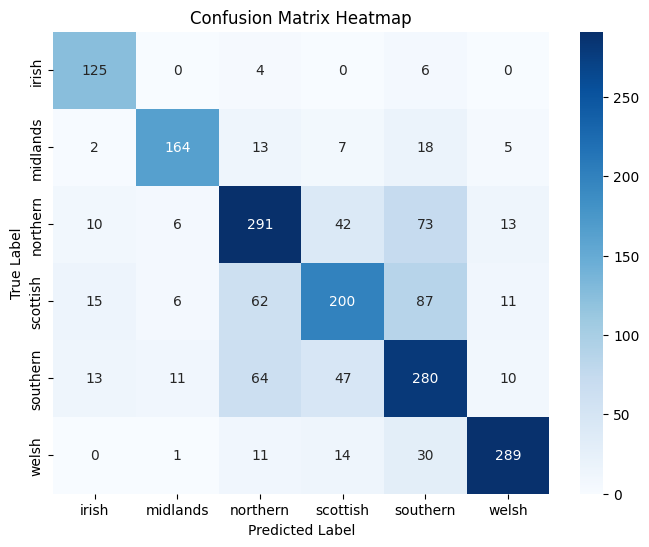

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# get loss and accuracy of model used on test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# make predictions from test set
y_pred = model.predict(X_test)

# get classes
classes = le.classes_

# get classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred.argmax(axis=1), target_names=classes))

# create confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()
